### 2차프로젝트 (고객이탈예측) - 분류모델 

In [49]:
import pandas as pd

df = pd.read_csv('data/bankchurners_clean.csv')

df

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Target
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0
10123,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,1
10124,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,1
10125,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,1


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10127 non-null  int64  
 1   Gender                    10127 non-null  str    
 2   Dependent_count           10127 non-null  int64  
 3   Education_Level           10127 non-null  str    
 4   Marital_Status            10127 non-null  str    
 5   Income_Category           10127 non-null  str    
 6   Card_Category             10127 non-null  str    
 7   Months_on_book            10127 non-null  int64  
 8   Total_Relationship_Count  10127 non-null  int64  
 9   Months_Inactive_12_mon    10127 non-null  int64  
 10  Contacts_Count_12_mon     10127 non-null  int64  
 11  Credit_Limit              10127 non-null  float64
 12  Total_Revolving_Bal       10127 non-null  int64  
 13  Avg_Open_To_Buy           10127 non-null  float64
 14  Total_Amt_Chng_Q4

In [51]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Target
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.160660
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.367235
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,1.000000


In [52]:
# 결측치 확인 
# 호우 ^0^ ~~
df.isnull().sum()

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
Target                      0
dtype: int64

In [53]:
# 문제(X) / 정답(y) 분리

X = df.drop(columns = ['Target'])
y = df['Target']

print(X.shape, y.shape)

(10127, 19) (10127,)


In [54]:
# 범주형 컬럼 
cat_cols = X.select_dtypes(include = ['object', 'str']).columns.tolist()

cat_cols

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [55]:
# 원-핫 인코딩 (범주형 -> 0/1 더미변수)
X = pd.get_dummies(X, columns = cat_cols, drop_first = True)

print(X.shape)

(10127, 32)


In [56]:
# 컬럼 총 32개 

X.columns.tolist()

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio',
 'Gender_M',
 'Education_Level_Doctorate',
 'Education_Level_Graduate',
 'Education_Level_High School',
 'Education_Level_Post-Graduate',
 'Education_Level_Uneducated',
 'Education_Level_Unknown',
 'Marital_Status_Married',
 'Marital_Status_Single',
 'Marital_Status_Unknown',
 'Income_Category_$40K - $60K',
 'Income_Category_$60K - $80K',
 'Income_Category_$80K - $120K',
 'Income_Category_Less than $40K',
 'Income_Category_Unknown',
 'Card_Category_Gold',
 'Card_Category_Platinum',
 'Card_Category_Silver']

In [57]:
# train / validation / test 나누기 !! (6:2:2)

from sklearn.model_selection import train_test_split

# 1차분할 (train(60) temp(40))
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size = 0.4,
    random_state = 42,
    stratify = y
)

print(X_train.shape, X_temp.shape)
print(y_train.shape, y_temp.shape)

(6076, 32) (4051, 32)
(6076,) (4051,)


In [58]:
# 2차 분할 (temp -> val(20), test(20))
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp
)

print(X_val.shape, X_test.shape)
print(y_val.shape, y_test.shape)

(2025, 32) (2026, 32)
(2025,) (2026,)


### LogisticRegression

In [59]:
# 스케일링

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(X_train_scaled)

[[-2.97260231e-01  1.27115102e+00 -3.78241225e-01 ... -1.11037037e-01
  -4.25873817e-02 -2.38494145e-01]
 [-4.22236232e-01  5.02871543e-01 -1.22033315e-03 ... -1.11037037e-01
  -4.25873817e-02 -2.38494145e-01]
 [-4.22236232e-01  5.02871543e-01 -8.80935747e-01 ... -1.11037037e-01
  -4.25873817e-02 -2.38494145e-01]
 ...
 [-4.73082294e-02  1.27115102e+00 -7.55262117e-01 ... -1.11037037e-01
  -4.25873817e-02 -2.38494145e-01]
 [-4.22236232e-01 -2.65407938e-01 -3.78241225e-01 ...  9.00600400e+00
  -4.25873817e-02 -2.38494145e-01]
 [ 7.02547776e-01  5.02871543e-01  1.00416871e+00 ... -1.11037037e-01
  -4.25873817e-02 -2.38494145e-01]]


0에 가까울수록 -> 그 컬럼의 평균값과 비슷  
양수 -> 평균보다 큼  
음수 -> 평균보다 작음  

In [60]:
from sklearn.linear_model import LogisticRegression

# 틀리면 더 큰 가중치 
lr = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
lr.fit(X_train_scaled, y_train)

print("학습 완료!")

학습 완료!


validation은 마지막에 한번만 !!!@@ 

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 예측
y_pred = lr.predict(X_val_scaled)
y_proba = lr.predict_proba(X_val_scaled)[:, 1]

# 평가지표 계산
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_proba)

print(f"--LogisticRegression--")
print(f"정확도(accuracy) : {accuracy:.3f}")
print(f"정밀도(precision) : {precision:.3f}")
print(f"재현율(recall) : {recall:.3f}")
print(f"F1 : {f1:.3f}")
print(f"AUC : {auc:.3f}")

--LogisticRegression--
정확도(accuracy) : 0.841
정밀도(precision) : 0.504
재현율(recall) : 0.843
F1 : 0.631
AUC : 0.926


#### Logistic Regression 결과

- Accuracy(84.1%)는 착시: 이탈 비율이 16%라 전부 "유지"로 찍어도 84%가 나옴 (Accuracy 저주) → 신뢰 X
- Recall(84.3%)은 양호: 실제 이탈자 대부분을 잡아냄  
    - (class_weight='balanced' 옵션 적용)
- Precision(50.4%)은 낮음: 이탈이라 예측한 것 중 절반은 오답 → 리텐션 비용 낭비 가능(그래도 recall보다 손실비용적음)
- F1(0.631)은 Precision·Recall의 조화평균: Recall은 높은데 Precision이 낮아서, 둘을 종합한 F1은 중간 수준에 그침 → Precision을 끌어올려야 F1도 개선됨
- AUC(0.926)는 우수: 모델 자체 판별력은 좋음, Precision 문제는 threshold(0.5) 이슈일 수 있음 → 추후 재검토
    - 임계값 조정

### RandomForest 

트리모델은 스케일링 필요없음 !

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 200, class_weight = 'balanced', random_state = 42)
rf.fit(X_train, y_train)    # 스케일링 안하니까 원본 그대로 ㄱㄱ

print("학습 완료!")

학습 완료!


In [63]:
# 예측 
y_pred_rf = rf.predict(X_val)
y_proba_rf = rf.predict_proba(X_val)[:, 1]

# 평가지표 계산
accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)
auc_rf = roc_auc_score(y_val, y_proba_rf)

print(f"--RandomForest--")
print(f"정확도(accuracy) : {accuracy_rf:.3f}")
print(f"정밀도(precision) : {precision_rf:.3f}")
print(f"재현율(recall) : {recall_rf:.3f}")
print(f"F1 : {f1_rf:.3f}")
print(f"AUC : {auc_rf:.3f}")

--RandomForest--
정확도(accuracy) : 0.951
정밀도(precision) : 0.834
재현율(recall) : 0.868
F1 : 0.851
AUC : 0.986


#### RandomForest 결과

- 로지스틱회귀 대비 전 지표에서 큰 폭으로 개선됨 ! 
- 특히 정밀도(precision)이 대폭 상승 
- 재현율(recall)도 함께 상승 (트레이드오프 없이 둘다 개선됨)
- auc 0.986으로 판별력도 매우 우수한 편 

### XGBoost

In [64]:
from xgboost import XGBClassifier

# 불균형 비율 계산 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# 틀리면 더 큰 벌점 ㄱㄱ 
print("scale_pos_weight: ", scale_pos_weight)  # train데이터 안에서 유지 고객이 이탈고객보다 5.2배 많다~로 출력

xgb = XGBClassifier(
    n_estimators = 200,
    eval_metric = 'logloss',
    scale_pos_weight = scale_pos_weight,   
    random_state = 42
)

xgb.fit(X_train, y_train)

print("학습 완료!")

scale_pos_weight:  5.225409836065574
학습 완료!


In [65]:
# 예측 
y_pred_xgb = xgb.predict(X_val)
y_proba_xgb = xgb.predict_proba(X_val)[:, 1]

# 평가지표 계산
accuracy_xgb = accuracy_score(y_val, y_pred_xgb)
precision_xgb = precision_score(y_val, y_pred_xgb)
recall_xgb = recall_score(y_val, y_pred_xgb)
f1_xgb = f1_score(y_val, y_pred_xgb)
auc_xgb = roc_auc_score(y_val, y_proba_xgb)

print(f"--XGBoost--")
print(f"정확도(accuracy) : {accuracy_xgb:.3f}")
print(f"정밀도(precision) : {precision_xgb:.3f}")
print(f"재현율(recall) : {recall_xgb:.3f}")
print(f"F1 : {f1_xgb:.3f}")
print(f"AUC : {auc_xgb:.3f}")

--XGBoost--
정확도(accuracy) : 0.966
정밀도(precision) : 0.886
재현율(recall) : 0.908
F1 : 0.897
AUC : 0.993


#### XGBoost 결과 

- 지금까지 비교한 3개 모델 중 최고 성능 !! 
- Boosting 방식이 랜덤포레스트 병렬 방식보다 이 데이터에서 더 효과적 ! 
- auc 1에 거의 근접 (완벽에 가까운 판별력)

### LightGBM

In [66]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators = 200,
    class_weight = 'balanced',
    random_state = 42,
)

lgbm.fit(X_train, y_train)

print("학습 완료!")


학습 완료!


In [67]:
# 예측
y_pred_lgbm = lgbm.predict(X_val)
y_proba_lgbm = lgbm.predict_proba(X_val)[:, 1]

# 평가지표 계산
accuracy_lgbm = accuracy_score(y_val, y_pred_lgbm)
precision_lgbm = precision_score(y_val, y_pred_lgbm)
recall_lgbm = recall_score(y_val, y_pred_lgbm)
f1_lgbm = f1_score(y_val, y_pred_lgbm)
auc_lgbm = roc_auc_score(y_val, y_proba_lgbm)

print(f"--LightGBM--")
print(f"정확도(accuracy) : {accuracy_lgbm:.3f}")
print(f"정밀도(precision) : {precision_lgbm:.3f}")
print(f"재현율(recall) : {recall_lgbm:.3f}")
print(f"F1 : {f1_lgbm:.3f}")
print(f"AUC : {auc_lgbm:.3f}")


--LightGBM--
정확도(accuracy) : 0.968
정밀도(precision) : 0.894
재현율(recall) : 0.908
F1 : 0.901
AUC : 0.994


#### LightGBM 결과

- 4개 모델 중 최고 성능 !! (XGBoost보다 근소하게 우위)

### MLP (다층 퍼셉트론)(신경망)

In [68]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes = (64, 32), max_iter = 500, random_state = 42)
mlp.fit(X_train_scaled, y_train)

print("학습 완료!")

학습 완료!


In [69]:
# 예측
y_pred_mlp = mlp.predict(X_val_scaled)
y_proba_mlp = mlp.predict_proba(X_val_scaled)[:, 1]

# 평가지표 계산
accuracy_mlp = accuracy_score(y_val, y_pred_mlp)
precision_mlp = precision_score(y_val, y_pred_mlp)
recall_mlp = recall_score(y_val, y_pred_mlp)
f1_mlp = f1_score(y_val, y_pred_mlp)
auc_mlp = roc_auc_score(y_val, y_proba_mlp)

print(f"--MLP--")
print(f"정확도(accuracy) : {accuracy_mlp:.3f}")
print(f"정밀도(precision) : {precision_mlp:.3f}")
print(f"재현율(recall) : {recall_mlp:.3f}")
print(f"F1 : {f1_mlp:.3f}")
print(f"AUC : {auc_mlp:.3f}")

--MLP--
정확도(accuracy) : 0.924
정밀도(precision) : 0.761
재현율(recall) : 0.766
F1 : 0.764
AUC : 0.958


### 7. 전체 모델 비교 및 최종 모델 선정

| 지표 | LR | RF | XGBoost | LightGBM | MLP |
|---|---|---|---|---|---|
| Accuracy | 0.841 | 0.951 | 0.966 | 0.968 | 0.924 |
| Precision | 0.504 | 0.834 | 0.886 | 0.894 | 0.761 |
| Recall | 0.843 | 0.868 | 0.908 | 0.908 | 0.766 |
| F1 | 0.631 | 0.851 | 0.897 | 0.901 | 0.764 |
| AUC | 0.926 | 0.986 | 0.993 | 0.994 | 0.958 |

#### 결론  
6개 모델을 비교한 결과, **LightGBM** 이 전 지표에서 최고 성능을 보여 최종 모델로 선정 ! 

- Boosting 계열(XGBoost, LightGBM)이 병렬 앙상블(RF)보다 우수
- 단일 나무(Decision Tree)는 과적합으로 앙상블 모델 대비 낮은 성능
- 신경망(MLP)은 class_weight 미지원 및 정형 데이터 특성상 트리 기반 모델보다 낮은 성능

**최종 모델: LightGBM**

### 모델별 성능 시각화 

In [70]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


# 정확도는 뺐음 !! (accuracy 저주(불균형데이터에서 착시 일으킴))
results = pd.DataFrame({
    "Model": ["LR", "RF", "XGBoost", "LightGBM", "MLP"],
    "Precision": [precision, precision_rf, precision_xgb, precision_lgbm, precision_mlp],
    "Recall": [recall, recall_rf, recall_xgb, recall_lgbm, recall_mlp],
    "F1": [f1, f1_rf, f1_xgb, f1_lgbm, f1_mlp],
    "AUC": [auc, auc_rf, auc_xgb, auc_lgbm, auc_mlp]
})

results

,Model,Precision,Recall,F1,AUC
0,LR,0.503676,0.843077,0.630610,0.926130
1,RF,0.834320,0.867692,0.850679,0.986044
2,XGBoost,0.885886,0.907692,0.896657,0.993086
3,LightGBM,0.893939,0.907692,0.900763,0.993976
4,MLP,0.761468,0.766154,0.763804,0.958043


정확도(accuracy)는 accuracy 저주로 뺐음 (불균형데이터에서 착시 일으킴)  

정밀도(Precision), 재현율(Recall)는 고객이탈예측에서 중요한 지표 !! 

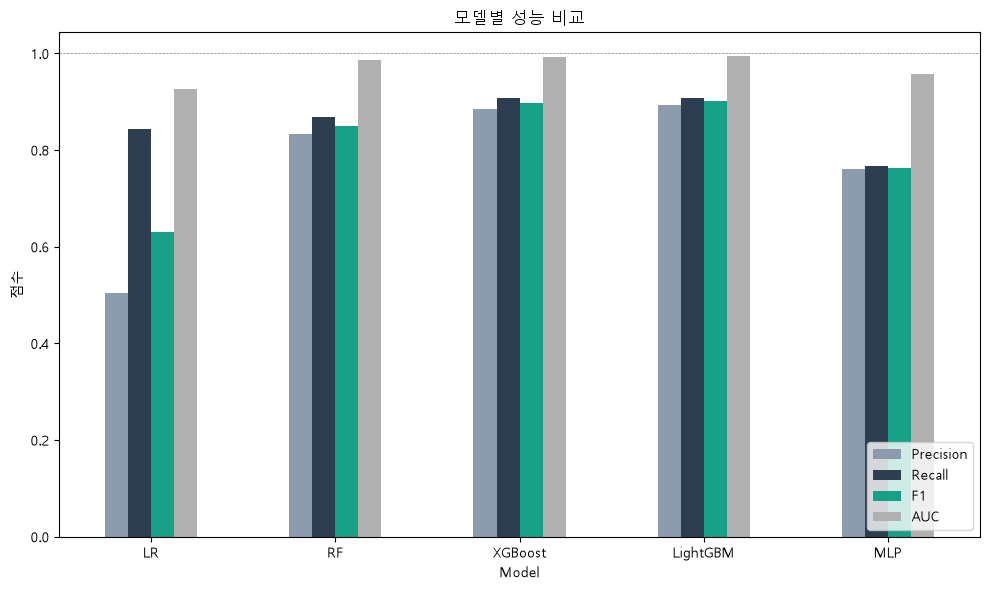

In [71]:
# 막대그래프 

results_plot = results.set_index('Model')

colors = ["#8C9BAB", "#2C3E50", "#16A085", "#B0B0B0"]

results_plot.plot(kind="bar", figsize=(10, 6), color = colors)
plt.title("모델별 성능 비교")
plt.ylabel("점수")
plt.legend(loc="lower right")
plt.xticks(rotation=0)
plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

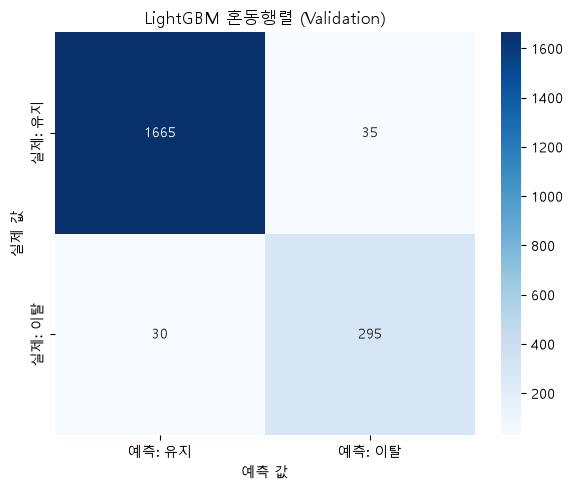

In [72]:
# 혼동행렬 (LightGMB 기준)

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_lgbm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["예측: 유지", "예측: 이탈"],
            yticklabels=["실제: 유지", "실제: 이탈"])
plt.title("LightGBM 혼동행렬 (Validation)")     # 모델 확정전이라 validation사용
plt.ylabel("실제 값")
plt.xlabel("예측 값")
plt.tight_layout()
plt.show()


validation 데이터 2,025명 중 실제 이탈 고객 325명  
30명은 놓쳤고 295명은 정확히 맞췄음  
30명 : '실제 매출 손실' <- 이 수치를 최소화하는것이 thrshold 최적화 목표 

### feature importance (lightGBM)

In [73]:
# 피처 중요도 
importance = pd.Series(lgbm.feature_importances_, index=X_train.columns)
importance_sorted = importance.sort_values(ascending=False)

print(importance_sorted.head(10))

Total_Trans_Amt             1176
Total_Amt_Chng_Q4_Q1         720
Total_Trans_Ct               619
Total_Ct_Chng_Q4_Q1          547
Total_Revolving_Bal          415
Customer_Age                 387
Total_Relationship_Count     286
Avg_Open_To_Buy              285
Months_on_book               266
Credit_Limit                 258
dtype: int32


정리 
| 순위 | 변수 | 중요도 |
|---|---|---|
| 1 | Total_Trans_Amt | 1176 |
| 2 | Total_Amt_Chng_Q4_Q1 | 720 |
| 3 | Total_Trans_Ct | 619 |
| 4 | Total_Ct_Chng_Q4_Q1 | 547 |
| 5 | Total_Revolving_Bal | 415 |

### 해석
- 상위 4개 모두 "거래활동성" 그룹 → 상관분석 결과와 일관됨
- Total_Trans_Amt와 Total_Trans_Ct는 서로 연관된 지표라, 모델이 둘 중 하나를 
  대표로 더 자주 사용한 것으로 해석
- Customer_Age가 6위로 예상보다 높게 등장 → 단독 상관관계는 낮았으나, 
  다른 변수와의 조합에서 유의미하게 활용된 것으로 추정

### LightGBM 하이퍼파라미터 튜닝

In [74]:
# GridSearchCV 

from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70]
}

lgbm_base = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

grid_search = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("최적 파라미터:", grid_search.best_params_)
print("최고 F1 (CV 평균):", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 31}
최고 F1 (CV 평균): 0.9215443983597933


### 튜닝된 파라미터로 LightGBM 최종 재학습

In [75]:
# GridSearchCV에서 찾은 최적 파라미터로 최종 LightGBM 재학습

best_params = grid_search.best_params_
print("최적 파라미터: ", best_params)


lgbm_final = LGBMClassifier(
    **best_params,
    class_weight = 'balanced',
    random_state = 42,
    verbose = -1
)

lgbm_final.fit(X_train, y_train)

print("학습 완료!")

최적 파라미터:  {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 31}
학습 완료!


In [76]:
# 튜닝한 lightgbm 최종 검증 

y_pred_lgbm_final = lgbm_final.predict(X_val)
y_proba_lgbm_final = lgbm_final.predict_proba(X_val)[:, 1]

accuracy_lgbm_final = accuracy_score(y_val, y_pred_lgbm_final)
precision_lgbm_final = precision_score(y_val, y_pred_lgbm_final)
recall_lgbm_final = recall_score(y_val, y_pred_lgbm_final)
f1_lgbm_final = f1_score(y_val, y_pred_lgbm_final)
auc_lgbm_final = roc_auc_score(y_val, y_proba_lgbm_final)

print(f"--LightGBM (Tuned)--")
print(f"정확도(accuracy) : {accuracy_lgbm_final:.3f}")
print(f"정밀도(precision) : {precision_lgbm_final:.3f}")
print(f"재현율(recall) : {recall_lgbm_final:.3f}")
print(f"F1 : {f1_lgbm_final:.3f}")
print(f"AUC : {auc_lgbm_final:.3f}")


--LightGBM (Tuned)--
정확도(accuracy) : 0.968
정밀도(precision) : 0.904
재현율(recall) : 0.898
F1 : 0.901
AUC : 0.994


### Voting Ensemble

In [77]:
# 각 모델 예측 평균 

from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators = [
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm_final)
    ],
    voting = 'soft'
)

voting.fit(X_train, y_train)

print("학습 완료!")

학습 완료!


In [78]:
# voting 검증 

y_pred_voting = voting.predict(X_val)
y_proba_voting =  voting.predict_proba(X_val)[:, 1]

accuracy_voting = accuracy_score(y_val, y_pred_voting)
precision_voting = precision_score(y_val, y_pred_voting)
recall_voting = recall_score(y_val, y_pred_voting)
f1_voting = f1_score(y_val, y_pred_voting)
auc_voting = roc_auc_score(y_val, y_proba_voting)

print(f"--Voting Ensemble--")
print(f"정확도(accuracy) : {accuracy_voting:.3f}")
print(f"정밀도(precision) : {precision_voting:.3f}")
print(f"재현율(recall) : {recall_voting:.3f}")
print(f"F1 : {f1_voting:.3f}")
print(f"AUC : {auc_voting:.3f}")


--Voting Ensemble--
정확도(accuracy) : 0.966
정밀도(precision) : 0.891
재현율(recall) : 0.902
F1 : 0.896
AUC : 0.991


In [79]:
# 튜닝 / voting 비교 

results_final = pd.DataFrame({
    "Model" : ["LightGBM (Tuned)", "Voting"],
    "Accuracy" : [accuracy_lgbm_final, accuracy_voting],
    "Precision" : [precision_lgbm_final, precision_voting],
    "Recall" : [recall_lgbm_final, recall_voting],
    "F1" : [f1_lgbm_final, f1_voting],
    "AUC" : [auc_lgbm_final, auc_voting]
})

results_final

,Model,Accuracy,Precision,Recall,F1,AUC
0,LightGBM (Tuned),0.968395,0.904025,0.898462,0.901235,0.994092
1,Voting,0.966420,0.890578,0.901538,0.896024,0.991200


### Stacking Ensemble

In [80]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking = StackingClassifier(
    estimators= [
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm_final)
    ],
   final_estimator = LogisticRegression(),
   cv = 5
)

stacking.fit(X_train, y_train)

print("학습 완료!")



학습 완료!


In [81]:
# stacking 검증 

y_pred_stacking = stacking.predict(X_val)
y_proba_stacking = stacking.predict_proba(X_val)[:, 1]

accuracy_stacking = accuracy_score(y_val, y_pred_stacking)
precision_stacking = precision_score(y_val, y_pred_stacking)
recall_stacking = recall_score(y_val, y_pred_stacking)
f1_stacking = f1_score(y_val, y_pred_stacking)
auc_stacking = roc_auc_score(y_val, y_proba_stacking)

print(f"--stacking Ensemble--")
print(f"정확도(accuracy) : {accuracy_stacking:.3f}")
print(f"정밀도(precision) : {precision_stacking:.3f}")
print(f"재현율(recall) : {recall_stacking:.3f}")
print(f"F1 : {f1_stacking:.3f}")
print(f"AUC : {auc_stacking:.3f}")


--stacking Ensemble--
정확도(accuracy) : 0.966
정밀도(precision) : 0.900
재현율(recall) : 0.886
F1 : 0.893
AUC : 0.991


In [82]:
# 세 모델 비교 (튜닝, voting, stacking)

results_final2 = pd.DataFrame({
    "Model" : ["LightGBM (Tuned)", "Voting", "Stacking"],
    "Accuracy" : [accuracy_lgbm_final, accuracy_voting, accuracy_stacking],
    "Precision" : [precision_lgbm_final, precision_voting, precision_stacking],
    "Recall" : [recall_lgbm_final, recall_voting, recall_stacking],
    "F1" : [f1_lgbm_final, f1_voting, f1_stacking],
    "AUC" : [auc_lgbm_final, auc_voting, auc_stacking]
})

results_final2

,Model,Accuracy,Precision,Recall,F1,AUC
0,LightGBM (Tuned),0.968395,0.904025,0.898462,0.901235,0.994092
1,Voting,0.966420,0.890578,0.901538,0.896024,0.991200
2,Stacking,0.965926,0.900000,0.886154,0.893023,0.990713


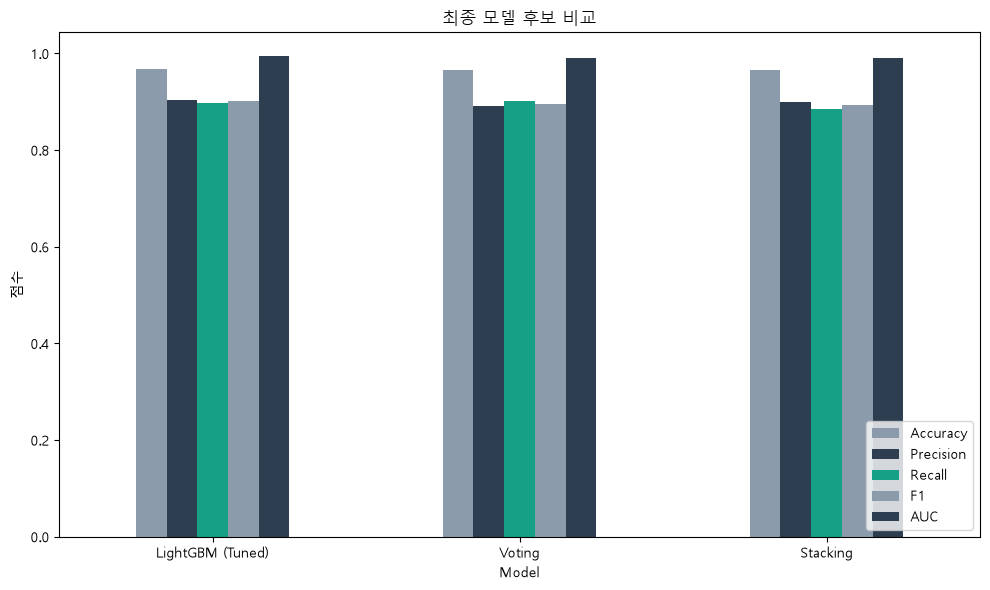

In [83]:
results_final2_plot = results_final2.set_index('Model')   # 어떤 컬럼을 인덱스로?

colors = ["#8C9BAB", "#2C3E50", "#16A085"]   # 모델 3개니까 색 3개만

results_final2_plot.plot(kind="bar", figsize=(10, 6), color = colors)
plt.title('최종 모델 후보 비교')
plt.ylabel("점수")
plt.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### 튜닝 / 앙상블 비교 결과 해석

- 3개 후보(튜닝 LightGBM / Voting / Stacking) 중   
튜닝된 LightGBM 단독이 Precision·F1·AUC 전 지표에서 최고 (F1 0.901, AUC 0.994)  
- Voting, Stacking 둘 다 오히려 단일 LightGBM보다 소폭 낮음 (F1 0.896 / 0.893)

  - 즉 이 데이터에서는 "모델 3개를 섞는 것"보다 "가장 잘하는 모델 하나에 집중하는 것"이 더 효율적
- GridSearchCV 튜닝 자체의 개선폭은 크지 않았음 (최적 파라미터가 LightGBM 기본값과 거의 동일 — n_estimators만 200→500으로 증가)   
→ 데이터/피처가 이미 LightGBM 기본 설정에 잘 맞는 상태였던 것으로 보임

#### 결론
앙상블(Voting/Stacking)은 이번 프로젝트에서 유의미한 성능 개선을 주지 못했으므로,   
**튜닝된 LightGBM** 을 최종 모델로 확정

In [84]:
# 최종모델 확정 !
final_model = lgbm_final

### Test셋 최종평가 (처음이자 마지막!!)

In [ ]:
# Test셋 최종 평가 (처음이자 마지막으로 !!)

y_pred_test = final_model.predict(X_test)
y_proba_test = final_model.predict_proba(X_test)[:, 1]

accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, y_proba_test)

print(f"--Final Model (Test) --")
print(f"정확도(accuracy) : {accuracy_test:.3f}")
print(f"정밀도(precision) : {precision_test:.3f}")
print(f"재현율(recall) : {recall_test:.3f}")
print(f"F1 : {f1_test:.3f}")
print(f"AUC : {auc_test:.3f}")

--Final Model (Test) --
정확도(accuracy) : 0.977
정밀도(precision) : 0.946
재현율(recall) : 0.911
F1 : 0.928
AUC : 0.993


In [86]:
# Validation vs Test 비교 (과적합 여부 확인용)
results_test = pd.DataFrame({
    "구분" : ["Validation", "Test"],
    "Accuracy" : [accuracy_lgbm_final, accuracy_test],
    "Precision" : [precision_lgbm_final, precision_test],
    "Recall" : [recall_lgbm_final, recall_test],
    "F1" : [f1_lgbm_final, f1_test],
    "AUC" : [auc_lgbm_final, auc_test]
})

results_test

,구분,Accuracy,Precision,Recall,F1,AUC
0,Validation,0.968395,0.904025,0.898462,0.901235,0.994092
1,Test,0.977295,0.945860,0.911043,0.928125,0.993268


test가 validation보다 결과가 더 좋음 ! (과적합 문제 없음)  
=> 새로운 데이터에서도 결과가 잘 나올것으로 기대됨 !

### 최종모델 혼동행렬 (Test)

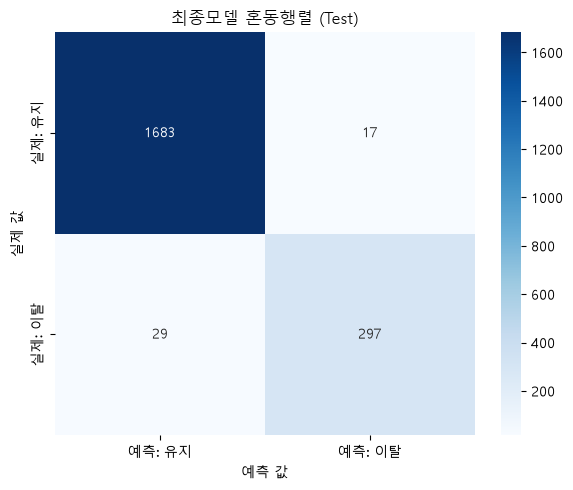

In [87]:
# 혼동행렬 (최종모델 기준, Test)

cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["예측: 유지", "예측: 이탈"],
            yticklabels=["실제: 유지", "실제: 이탈"])
plt.title("최종모델 혼동행렬 (Test)")
plt.ylabel("실제 값")
plt.xlabel("예측 값")
plt.tight_layout()
plt.show()

### 최종모델 Feature Importance

In [88]:
# 최종모델 피처 중요도 (표로 정리)
importance_final = pd.Series(final_model.feature_importances_, index=X_train.columns)
importance_final_sorted = importance_final.sort_values(ascending=False).head(10)

importance_df = importance_final_sorted.reset_index()
importance_df.columns = ["변수명", "중요도"]

importance_df

,변수명,중요도
0,Total_Trans_Amt,2620
1,Total_Amt_Chng_Q4_Q1,1736
2,Total_Trans_Ct,1494
3,Total_Ct_Chng_Q4_Q1,1329
4,Customer_Age,976
5,Total_Revolving_Bal,964
6,Credit_Limit,763
7,Avg_Open_To_Buy,742
8,Months_on_book,677
9,Total_Relationship_Count,622


### 결과 해석 
- 튜닝 전과 상위 4개  
(Total_Trans_Amt, Total_Amt_Chng_Q4_Q1, Total_Trans_Ct, Total_Ct_Chng_Q4_Q1) 순위가 동일  
→ 거래활동성 지표가 이탈 예측 핵심이라는 결론은 튜닝 후에도 변하지 않음   

- 튜닝 후 Credit_Limit(10위→7위), Customer_Age(6위→5위)의 상대적 중요도가 소폭 상승  
- 반면 Total_Relationship_Count는 7위→10위로 순위 하락 → 핵심 변수(거래활동성) 비중이 커지며 상대적으로 영향력이 줄어듦



### SHAP 분석

모델의 예측 결과를 각 입력 변수(Feature)가 얼마나 기여했는지 수치화

In [89]:
import shap

explainer = shap.TreeExplainer(final_model) # lighgbm(트리기반모델) 분석
shap_values = explainer.shap_values(X_val)

print(type(shap_values))
print(len(shap_values) if isinstance(shap_values, list) else shap_values.shape)
# (2025명의 고객(X_val), 32개 변수)

<class 'numpy.ndarray'>
(2025, 32)


c:\Users\Playdata2\Desktop\study\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


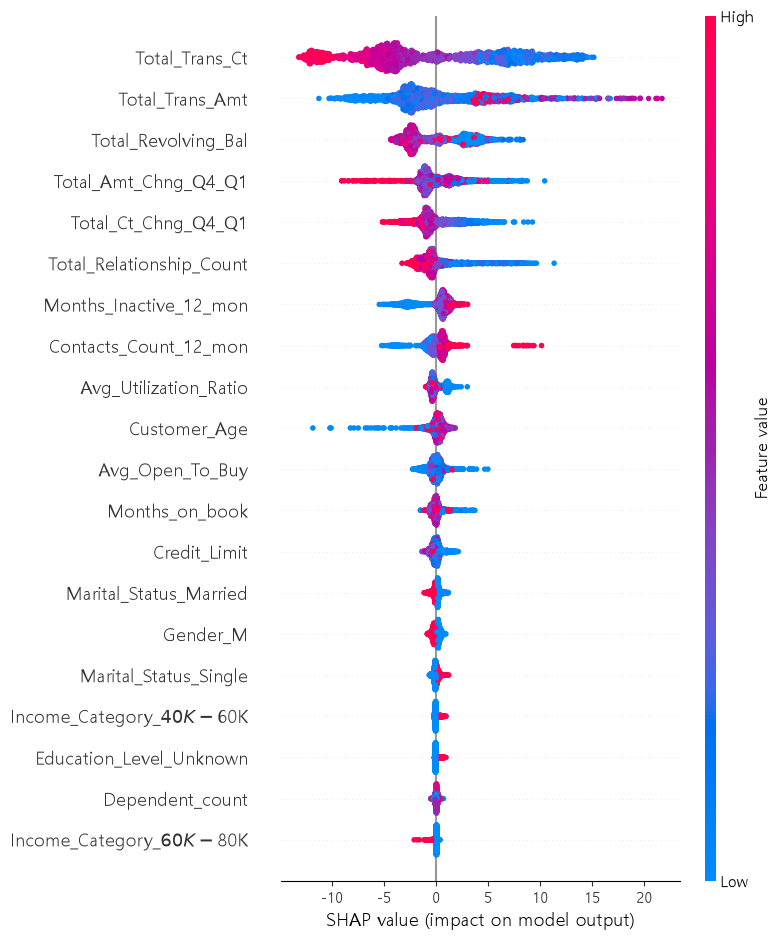

In [90]:
shap.summary_plot(shap_values, X_val)

#### SHAP summary plot 해석

x축(SHAP value)이 양수면 이탈확률을 높이는 방향,   
음수면 낮추는 방향.   
점 색깔은 실제 변수값(빨강=높음, 파랑=낮음).

- Total_Trans_Ct (거래건수, 1위) : 파란 점(거래건수 낮음)이 오른쪽에 몰려있음 → 거래건수가 적을수록 이탈확률이 크게 상승. 가장 강력한 이탈 신호
- Total_Trans_Amt (거래금액): 비슷한 패턴 — 거래금액이 낮을수록 이탈확률 상승
- Total_Revolving_Bal (리볼빙 잔액): 반대 패턴 — 잔액이 높을수록(빨강) 이탈확률 감소. 리볼빙 잔액을 유지하는 고객일수록 오히려 안 떠남
- Total_Relationship_Count (보유 상품 개수): 파란 점(적은 상품 보유)이 오른쪽 멀리까지 퍼져있어 매우 강한 신호 → 보유 상품이 적을수록 이탈 위험 급증
- Months_Inactive_12_mon (비활성 개월수): 빨간 점(비활성 기간 김)이 오른쪽 → 오래 안 쓸수록 이탈확률 상승
- Contacts_Count_12_mon (문의 횟수): 빨간 점(문의 많음)이 오른쪽 → 고객센터 문의가 잦을수록 이탈 위험 높음 (불만 누적 신호로 해석 가능)
- 하위 변수(Avg_Utilization_Ratio 이하)는 점들이 0 근처에 몰려있어 예측에 미치는 영향이 미미함. 

### 결론: 
Feature Importance에서 확인한 "거래활동성 그룹"이 SHAP에서도 최상위로 재확인됨 (두 방법 결론 일치)  
  거래활동성·상품보유는 낮을수록 위험, 비활성기간·문의횟수는 높을수록 위험, 리볼빙잔액은 오히려 있는 게 안전 신호.   
  인구통계 변수는 이탈 예측에 거의 기여하지 않음 → 비즈니스 액션은 거래활동성 모니터링 위주로 설계하는 것이 좋을것으로 예상 

### 비즈니스 적용 — Lift/Gain 분석 및 고위험군 타겟팅

모든 고객에게 리텐션 혜택을 줄 수는 없으므로,   
"상위 몇 %만 타겟팅해도 실제 이탈자의 몇 %를 잡아낼 수 있는가"를 정량적으로 확인함   
(최종모델 기준, Test셋 이탈확률 사용)

In [91]:
# 이탈확률 기준 정렬
risk_df = pd.DataFrame({
    "고객ID": X_test.index,
    "이탈확률": y_proba_test,
    "실제_이탈여부": y_test.values,
}).sort_values("이탈확률", ascending=False).reset_index(drop=True)

total_churners = risk_df["실제_이탈여부"].sum()
print(f"Test셋 전체 이탈자 수: {total_churners}명\n")

print("상위 K% 타겟팅 시 실제 이탈자 포착률 (무작위 타겟팅 대비 효율):")
for pct in [0.05, 0.10, 0.20, 0.30, 0.50]:
    top_n = int(len(risk_df) * pct)
    captured = risk_df.iloc[:top_n]["실제_이탈여부"].sum()
    capture_rate = captured / total_churners * 100
    lift = capture_rate / (pct * 100)
    print(f"  상위 {int(pct*100):>2}% 타겟팅 → 이탈자 포착률 {capture_rate:5.1f}%  (무작위 대비 {lift:.1f}배 효율)")

Test셋 전체 이탈자 수: 326명

상위 K% 타겟팅 시 실제 이탈자 포착률 (무작위 타겟팅 대비 효율):
  상위  5% 타겟팅 → 이탈자 포착률  31.0%  (무작위 대비 6.2배 효율)
  상위 10% 타겟팅 → 이탈자 포착률  61.7%  (무작위 대비 6.2배 효율)
  상위 20% 타겟팅 → 이탈자 포착률  96.3%  (무작위 대비 4.8배 효율)
  상위 30% 타겟팅 → 이탈자 포착률  99.1%  (무작위 대비 3.3배 효율)
  상위 50% 타겟팅 → 이탈자 포착률 100.0%  (무작위 대비 2.0배 효율)


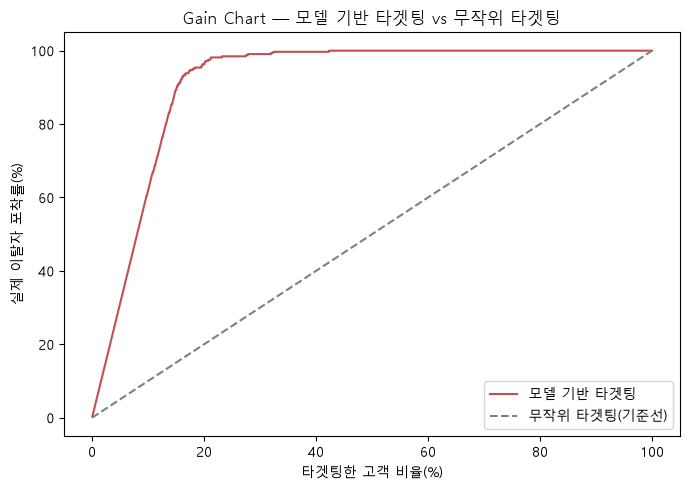

In [92]:
# Gain Chart 시각화
risk_df["누적_이탈자_포착"] = risk_df["실제_이탈여부"].cumsum()
risk_df["누적_비율"] = (risk_df.index + 1) / len(risk_df) * 100
risk_df["누적_포착률"] = risk_df["누적_이탈자_포착"] / total_churners * 100

plt.figure(figsize=(7, 5))
plt.plot(risk_df["누적_비율"], risk_df["누적_포착률"], label="모델 기반 타겟팅", color="#C44E52")
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", label="무작위 타겟팅(기준선)")
plt.xlabel("타겟팅한 고객 비율(%)")
plt.ylabel("실제 이탈자 포착률(%)")
plt.title("Gain Chart — 모델 기반 타겟팅 vs 무작위 타겟팅")
plt.legend()
plt.tight_layout()
plt.show()

In [93]:
# 고위험군 명단 (이탈확률 90% 이상 - 임계값 기준 필터)
high_risk = risk_df[risk_df["이탈확률"] >= 0.9][["고객ID", "이탈확률", "실제_이탈여부"]].copy()
high_risk["이탈확률"] = (high_risk["이탈확률"] * 100).round(1)
high_risk.columns = ["고객ID", "이탈확률(%)", "실제_이탈여부(검증용)"]

print(f"이탈확률 90% 이상 고위험 고객: {len(high_risk)}명")
high_risk.head(10)

이탈확률 90% 이상 고위험 고객: 298명


,고객ID,이탈확률(%),실제_이탈여부(검증용)
0,6244,100.0,1
1,5925,100.0,1
2,7253,100.0,1
3,7974,100.0,1
4,564,100.0,1
5,8120,100.0,1
6,4273,100.0,1
7,8044,100.0,1
8,8294,100.0,1
9,8334,100.0,1


### 정리

- 상위 10%만 타겟팅해도 실제 이탈자의 61.7%를 잡아낼 수 있음 (무작위 대비 6.2배 효율)   
    → 전체 고객에게 리텐션 비용을 쓸 필요 없이, 상위 위험군 위주로 예산을 집중하는 것이 효율적
- 이탈확률 90% 이상 고위험군(298명) 리스트를 상담팀이 바로 활용할 수 있는 컨택 대상 형태로 정리
- SHAP 분석 결과와 연결하면, 고위험군 컨택 시 "거래활동 감소", "상품 보유 축소", "장기 미사용" 여부를 우선 확인하는 것이 효과적인 리텐션 전략이 될 것으로 예상

shap 분석만으로는 이탈원인 다 설명할순없지만 !!  
분석해서 나온 변수로 이탈 원인 유형 분류 ㄱㄱ (fact데이터 구할순없나 ? -> 없는거 확인)

구체적 이탈 원인 유형
(ex. 수익실현 후 이탈, 이벤트 반응형 체리피커, 자산방치형 자연이탈 등)  
유형별로 다른 리텐션 캠페인 설계 필요   

- 거래활동 급감형 (Total_Trans_Amt/Ct가 top driver)
- 관계 축소형 (Total_Relationship_Count가 top driver)
- 장기 미사용형 (Months_Inactive_12_mon이 top driver)
- 불만 누적형 (Contacts_Count_12_mon이 top driver)


이 분석 유형은 b2c 마케팅에 좀 더 가까움 


In [94]:
# Test셋 고객 대상 SHAP 값 계산 (고위험군 리스트와 population 맞추기 위함)
shap_values_test = explainer.shap_values(X_test)

# 고객별 SHAP 기여도 1위 변수 찾기
top_feature_idx = shap_values_test.argmax(axis=1)
top_feature_name = X_test.columns[top_feature_idx]

reason_map = {
    "Total_Trans_Amt": "거래활동 급감형",
    "Total_Trans_Ct": "거래활동 급감형",
    "Total_Amt_Chng_Q4_Q1": "거래활동 급감형",
    "Total_Ct_Chng_Q4_Q1": "거래활동 급감형",
    "Total_Relationship_Count": "관계 축소형",
    "Months_Inactive_12_mon": "장기 미사용형",
    "Contacts_Count_12_mon": "불만 누적형",
    "Total_Revolving_Bal": "관계 축소형",
}

churn_reason = pd.Series(top_feature_name, index=X_test.index).map(reason_map).fillna("기타")

risk_df_reason = risk_df.copy()
risk_df_reason["주요원인"] = risk_df_reason["고객ID"].map(churn_reason)

print("이탈원인 유형별 분포:")
print(risk_df_reason["주요원인"].value_counts())

이탈원인 유형별 분포:
주요원인
거래활동 급감형    1352
관계 축소형       372
장기 미사용형      127
기타           107
불만 누적형        68
Name: count, dtype: int64


c:\Users\Playdata2\Desktop\study\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [95]:
# 고위험군 명단에 이탈원인 유형 결합
high_risk_reason = risk_df_reason[risk_df_reason["이탈확률"] >= 0.9][
    ["고객ID", "이탈확률", "주요원인", "실제_이탈여부"]
].copy()
high_risk_reason["이탈확률"] = (high_risk_reason["이탈확률"] * 100).round(1)
high_risk_reason.columns = ["고객ID", "이탈확률(%)", "주요원인", "실제_이탈여부(검증용)"]

print(f"고위험군({len(high_risk_reason)}명) 중 이탈원인 유형별 분포:")
print(high_risk_reason["주요원인"].value_counts())
high_risk_reason.head(10)

고위험군(298명) 중 이탈원인 유형별 분포:
주요원인
거래활동 급감형    292
관계 축소형        6
Name: count, dtype: int64


,고객ID,이탈확률(%),주요원인,실제_이탈여부(검증용)
0,6244,100.0,거래활동 급감형,1
1,5925,100.0,거래활동 급감형,1
2,7253,100.0,거래활동 급감형,1
3,7974,100.0,거래활동 급감형,1
4,564,100.0,거래활동 급감형,1
5,8120,100.0,거래활동 급감형,1
6,4273,100.0,거래활동 급감형,1
7,8044,100.0,거래활동 급감형,1
8,8294,100.0,거래활동 급감형,1
9,8334,100.0,거래활동 급감형,1


#### 이탈원인 유형 분류 해석

- SHAP 분석에서 확인한 핵심 변수(거래활동성, 상품보유, 비활성기간, 문의횟수)를 기준으로, 고위험군 298명을 4가지 유형으로 재분류함
- 유형별로 다른 대응이 필요함:
  - **거래활동 급감형**: 카드 사용 유도 캠페인(캐시백, 할인 프로모션)이 효과적일 것으로 예상
  - **관계 축소형**: 추가 상품 교차판매(크로스셀) 제안으로 lock-in 강화
  - **장기 미사용형**: 재활성화(reactivation) 캠페인, 휴면계정 알림
  - **불만 누적형**: 상담 이력 확인 후 문제 해결 우선 — 단순 프로모션보다 근본 원인(CS 이슈) 해소가 필요
- 참고: 나광택 외(2020), "증권 금융 상품 거래 고객의 이탈 예측 및 원인 추론", 한국빅데이터학회지 —   
SHAP만으로는 이탈 원인을 다 설명할 수 없어, 변수 유형 조합으로 원인을 추론하는 방법론을 참고함



- **한계**: 고위험군(298명) 중 292명(98%)이 "거래활동 급감형"으로 쏠림 → Total_Trans_Amt/Ct가 SHAP 기준 압도적 1위 변수라 대부분 고객의 최상위 기여 변수가 동일하게 잡히는 구조적 특성.  
   유형 다양성은 오히려 중~저위험군에서 더 잘 드러남 (전체 분포: 거래활동 급감형 1352, 관계축소형 372, 장기미사용형 127, 기타 107, 불만누적형 68)

### 피처엔지니어링 (추가 실험 — Validation까지만 비교, Test는 재사용 안 함)

SHAP 핵심 변수들을 조합한 비율형 파생변수 3개를 추가해 성능 개선 여부를 확인함
- 거래건당_평균금액 = Total_Trans_Amt / Total_Trans_Ct
- 문의_대비_거래활동 = Contacts_Count_12_mon / (Total_Trans_Ct + 1)
- 비활성_비율 = Months_Inactive_12_mon / Months_on_book

In [96]:
# 파생변수 생성
df_fe = df.copy()
df_fe["거래건당_평균금액"] = df_fe["Total_Trans_Amt"] / df_fe["Total_Trans_Ct"]
df_fe["문의_대비_거래활동"] = df_fe["Contacts_Count_12_mon"] / (df_fe["Total_Trans_Ct"] + 1)
df_fe["비활성_비율"] = df_fe["Months_Inactive_12_mon"] / df_fe["Months_on_book"]

X_fe = df_fe.drop(columns=["Target"])
cat_cols_fe = X_fe.select_dtypes(include=["object", "str"]).columns.tolist()
X_fe = pd.get_dummies(X_fe, columns=cat_cols_fe, drop_first=True)

print("파생변수 추가 후 shape:", X_fe.shape)

# 원본과 동일한 random_state로 재분할 (같은 고객 구성 유지)
X_train_fe, X_temp_fe, y_train_fe, y_temp_fe = train_test_split(
    X_fe, y, test_size=0.4, random_state=42, stratify=y
)
X_val_fe, X_test_fe, y_val_fe, y_test_fe = train_test_split(
    X_temp_fe, y_temp_fe, test_size=0.5, random_state=42, stratify=y_temp_fe
)

print(X_train_fe.shape, X_val_fe.shape, X_test_fe.shape)

파생변수 추가 후 shape: (10127, 35)
(6076, 35) (2025, 35) (2026, 35)


In [97]:
# 튜닝된 파라미터 그대로, 파생변수 추가 데이터로 재학습
lgbm_fe = LGBMClassifier(
    **best_params,
    class_weight = 'balanced',
    random_state = 42,
    verbose = -1
)
lgbm_fe.fit(X_train_fe, y_train_fe)

y_pred_fe = lgbm_fe.predict(X_val_fe)
y_proba_fe = lgbm_fe.predict_proba(X_val_fe)[:, 1]

accuracy_fe = accuracy_score(y_val_fe, y_pred_fe)
precision_fe = precision_score(y_val_fe, y_pred_fe)
recall_fe = recall_score(y_val_fe, y_pred_fe)
f1_fe = f1_score(y_val_fe, y_pred_fe)
auc_fe = roc_auc_score(y_val_fe, y_proba_fe)

print(f"--LightGBM + 파생변수 (Validation)--")
print(f"정확도(accuracy) : {accuracy_fe:.3f}")
print(f"정밀도(precision) : {precision_fe:.3f}")
print(f"재현율(recall) : {recall_fe:.3f}")
print(f"F1 : {f1_fe:.3f}")
print(f"AUC : {auc_fe:.3f}")

--LightGBM + 파생변수 (Validation)--
정확도(accuracy) : 0.970
정밀도(precision) : 0.915
재현율(recall) : 0.898
F1 : 0.907
AUC : 0.994


In [99]:
# 원본 피처 vs 파생변수 추가 비교 (Validation 기준)
results_fe = pd.DataFrame({
    "구분" : ["원본 피처 (최종모델)", "원본 + 파생변수 3개"],
    "Accuracy" : [accuracy_lgbm_final, accuracy_fe],
    "Precision" : [precision_lgbm_final, precision_fe],
    "Recall" : [recall_lgbm_final, recall_fe],
    "F1" : [f1_lgbm_final, f1_fe],
    "AUC" : [auc_lgbm_final, auc_fe]
})

results_fe

,구분,Accuracy,Precision,Recall,F1,AUC
0,원본 피처 (최종모델),0.968395,0.904025,0.898462,0.901235,0.994092
1,원본 + 파생변수 3개,0.970370,0.915361,0.898462,0.906832,0.994092


#### 파생변수 실험 해석

- 파생변수 3개(거래건당 평균금액, 문의 대비 거래활동, 비활성 비율) 추가 후 Validation 기준 Accuracy(0.968→0.970), Precision(0.904→0.915), F1(0.901→0.907)이 소폭 상승. Recall(0.898)과 AUC(0.994)는 거의 동일
- 개선폭이 크진 않지만 방향은 일관되게 긍정적 → 원본 피처가 이미 핵심 정보를 잘 담고 있었고, 파생변수는 이를 보완하는 수준
- 이 비교는 Validation 기준 추가 실험이며 Test는 재사용하지 않음. 최종 제출 모델은 기존 튜닝 LightGBM(원본 피처 기반, final_model)을 그대로 유지하고, 본 실험은 고도화 시도 중 하나로 기록

### B2B 비즈니스 분석 고도화

분류모델 결과를 바탕으로 B2B(은행 실무진 대상) 관점의 비즈니스 활용 방안 3가지를 추가
1. CLV × 이탈위험 매트릭스 — 리소스 우선순위 제안
2. 비용함수 기반 임계값 최적화 — 의사결정 근거 제시
3. 카드등급별 이탈원인 세그먼트 분석 — 상품 정책 제안

#### 1) CLV × 이탈위험 매트릭스

이탈확률과 고객가치(연간 거래액으로 근사)를 각각 중앙값 기준으로 나눠 4분면으로 분류  
'고위험·고가치' 고객에게 리텐션 자원을 우선 투입하자는 제안  

대응우선순위 분포:
대응우선순위
2순위: 고위험·저가치    670
3순위: 저위험·고가치    670
1순위: 고위험·고가치    343
4순위: 저위험·저가치    343
Name: count, dtype: int64


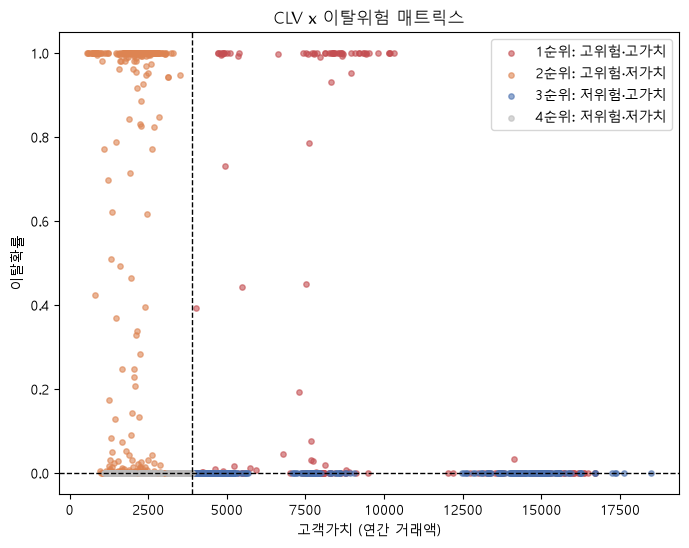

In [100]:
# 1) CLV(고객가치) x 이탈위험 매트릭스
risk_df_value = risk_df.copy()
risk_df_value["고객가치(연간거래액)"] = df.loc[risk_df_value["고객ID"], "Total_Trans_Amt"].values

risk_median = risk_df_value["이탈확률"].median()
value_median = risk_df_value["고객가치(연간거래액)"].median()

def quadrant(row):
    risk_high = row["이탈확률"] >= risk_median
    value_high = row["고객가치(연간거래액)"] >= value_median
    if risk_high and value_high:
        return "1순위: 고위험·고가치"
    elif risk_high and not value_high:
        return "2순위: 고위험·저가치"
    elif not risk_high and value_high:
        return "3순위: 저위험·고가치"
    else:
        return "4순위: 저위험·저가치"

risk_df_value["대응우선순위"] = risk_df_value.apply(quadrant, axis=1)

print("대응우선순위 분포:")
print(risk_df_value["대응우선순위"].value_counts())

plt.figure(figsize=(8, 6))
colors = {"1순위: 고위험·고가치": "#C44E52", "2순위: 고위험·저가치": "#DD8452",
          "3순위: 저위험·고가치": "#4C72B0", "4순위: 저위험·저가치": "#BBBBBB"}
for label, color in colors.items():
    subset = risk_df_value[risk_df_value["대응우선순위"] == label]
    plt.scatter(subset["고객가치(연간거래액)"], subset["이탈확률"], label=label, color=color, alpha=0.6, s=15)

plt.axhline(risk_median, color="black", linestyle="--", linewidth=1)
plt.axvline(value_median, color="black", linestyle="--", linewidth=1)
plt.xlabel("고객가치 (연간 거래액)")
plt.ylabel("이탈확률")
plt.title("CLV x 이탈위험 매트릭스")
plt.legend()
plt.show()

#### CLV × 이탈위험 매트릭스 해석

- 1순위(고위험·고가치) 343명 vs 2순위(고위험·저가치) 670명 → 이탈위험이 높다고 전부 동일하게 대응하면 비효율적. 실제 우선 투입 대상은 전체 고위험군(1,013명)의 1/3 수준인 343명
- 3순위(저위험·고가치) 670명은 당장 급하진 않지만 매출 기여도가 큰 고객군 → 캠페인 대상은 아니지만 장기 관계 유지(멤버십 혜택 등) 모니터링 대상으로 별도 관리 필요
- 결론: 이탈확률만 볼 게 아니라 고객가치까지 고려해 리소스를 배분하면, 동일 예산으로 더 높은 ROI를 기대할 수 있음 (고객가치까지는 현재 데이터로 어려움) 

#### 2) 비용함수 기반 임계값 최적화

지금까지는 기본 임계값 0.5를 사용  
하지만 '이탈 고객을 놓쳤을 때의 손실'과 '불필요한 캠페인 비용'은 크기가 다르므로, 두 비용을 가정해 총비용이 최소가 되는 임계값을 다시 탐색   
(실제 비용 데이터가 없어 합리적으로 가정한 값을 사용함)

가정 비용 - 이탈 고객 1명 놓칠 시: 4,404 / 불필요 캠페인 1건: 20,000
비용 최소화 임계값: 0.85 (기본값 0.5와 비교)


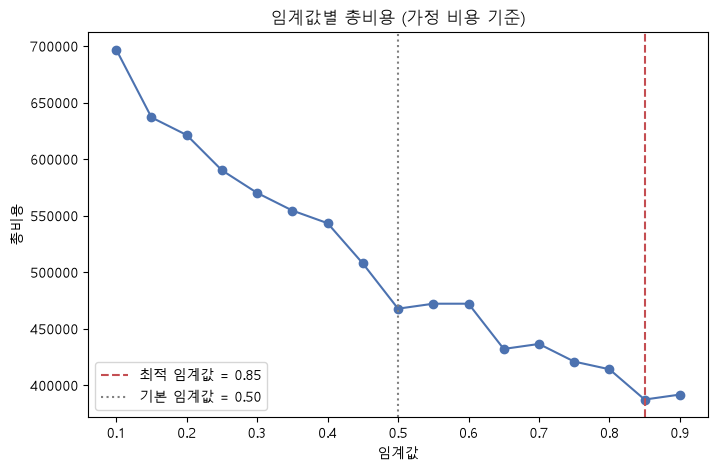

,임계값,총비용
0,0.10,696889.898687
1,0.15,636889.898687
2,0.20,621293.984991
3,0.25,590102.157598
4,0.30,570102.157598
5,0.35,554506.243902
6,0.40,543314.416510
7,0.45,507718.502814
8,0.50,467718.502814
9,0.55,472122.589118


In [101]:
# 2) 비용함수 기반 임계값 최적화
import numpy as np

cost_fn = df["Total_Trans_Amt"].mean()   # 이탈 고객 1명을 놓쳤을 때 잃는 가치 (연간 거래액 평균으로 근사)
cost_fp = 20000                           # 불필요하게 캠페인을 진행했을 때 드는 비용 (1인당, 가정치)

thresholds = np.arange(0.1, 0.91, 0.05)
total_costs = []

for t in thresholds:
    pred_t = (y_proba_test >= t).astype(int)
    fn = ((y_test == 1) & (pred_t == 0)).sum()
    fp = ((y_test == 0) & (pred_t == 1)).sum()
    total_costs.append(fn * cost_fn + fp * cost_fp)

cost_df = pd.DataFrame({"임계값": thresholds, "총비용": total_costs})
best_threshold = cost_df.loc[cost_df["총비용"].idxmin(), "임계값"]

print(f"가정 비용 - 이탈 고객 1명 놓칠 시: {cost_fn:,.0f} / 불필요 캠페인 1건: {cost_fp:,.0f}")
print(f"비용 최소화 임계값: {best_threshold:.2f} (기본값 0.5와 비교)")

plt.figure(figsize=(8, 5))
plt.plot(cost_df["임계값"], cost_df["총비용"], marker="o", color="#4C72B0")
plt.axvline(best_threshold, color="#C44E52", linestyle="--", label=f"최적 임계값 = {best_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="기본 임계값 = 0.50")
plt.xlabel("임계값")
plt.ylabel("총비용")
plt.title("임계값별 총비용 (가정 비용 기준)")
plt.legend()
plt.show()

cost_df

#### 비용함수 기반 임계값 해석

- 가정 비용(이탈 고객 1명 손실 4,404 vs 불필요 캠페인 1건 20,000) 기준, 총비용이 최소가 되는 임계값은 0.85로 기본값(0.5)보다 훨씬 보수적
- 캠페인 비용이 손실 비용보다 훨씬 커서, 폭넓게 접촉하기보다 확실한 고위험군만 좁혀서 타겟팅하는 것이 총비용 관점에서 더 유리함을 의미
- 흥미롭게도 앞서 임의로 잡았던 '이탈확률 90% 이상 고위험군' 기준(298명)이 비용 최적 임계값(0.85)과 크게 다르지 않음 → 직관적으로 잡은 기준이 비용 관점에서도 합리적이었음을 뒷받침
- 단, 비용 가정치는 실제 데이터가 아닌 추정값이므로 실제 운영 시에는 정확한 비용 데이터로 재산정이 필요함

#### 3) 카드등급별 이탈원인 세그먼트 분석

개인별 메시지 대신(B2C),   
카드등급(Card_Category)별로 어떤 이탈원인 유형이 두드러지는지 교차분석해 상품/정책 단위의 개선 제안으로 연결

카드등급별 이탈원인 유형 분포 (%):
주요원인      거래활동 급감형  관계 축소형   기타  불만 누적형  장기 미사용형
카드등급                                            
Blue          65.8    19.1  5.4     3.4      6.4
Gold          80.0     5.0  5.0    10.0      0.0
Platinum     100.0     0.0  0.0     0.0      0.0
Silver        78.2    10.5  4.0     2.4      4.8


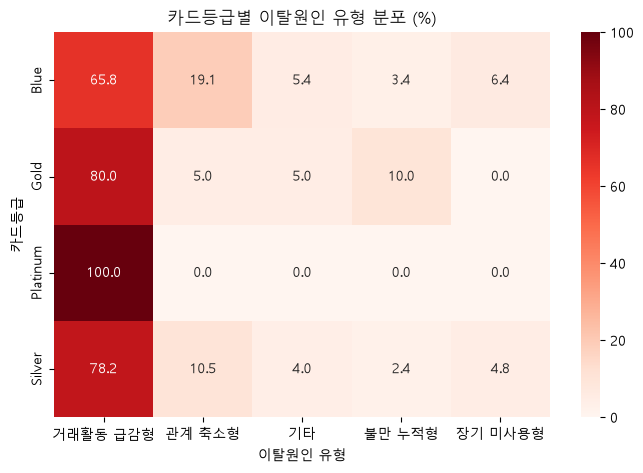

In [102]:
# 3) 카드등급별 이탈원인 세그먼트 분석
seg_df = risk_df_reason.copy()
seg_df["카드등급"] = df.loc[seg_df["고객ID"], "Card_Category"].values

cross_tab = pd.crosstab(seg_df["카드등급"], seg_df["주요원인"])
cross_tab_pct = (cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100).round(1)

print("카드등급별 이탈원인 유형 분포 (%):")
print(cross_tab_pct)

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab_pct, annot=True, fmt=".1f", cmap="Reds")
plt.title("카드등급별 이탈원인 유형 분포 (%)")
plt.ylabel("카드등급")
plt.xlabel("이탈원인 유형")
plt.show()

#### 카드등급별 세그먼트 해석

- Blue(일반등급)는 원인 유형이 비교적 고르게 분포(관계축소형 19.1%, 장기미사용형 6.4% 등) → 고객 수가 가장 많은 등급이라 원인별 맞춤 캠페인의 효과가 가장 클 것으로 예상
- Gold는 불만누적형 비중(10.0%)이 다른 등급보다 높음 → 프로모션보다 CS/컴플레인 이력 점검이 우선되어야 함
- Platinum은 100% 거래활동 급감형으로 나타나지만 표본 수가 매우 적은 등급이라 일반화하기 어려움 → 애초에 소수 VIP 고객이라 세그먼트 정책보다 개별 전담(RM) 관리가 더 적합
- 종합: 세그먼트 정책은 Blue/Silver 같은 대중 등급에 적용할 때 효율적이고, Platinum처럼 소수 등급은 1:1 대응이 더 합리적

In [ ]:
임계값 맞춰야되나 ? -> 아니 !!!!!!!!! 기준이 다르니까 !!! 다르게 쓴거야 !!!!!!!!!!!1
모델 예측 : 0.5
고위험군 리스트 : 0.9 (보수적으로 확실한 고객만)
비용 최적화 : 0.85

In [ ]:

clv 고객 가치 진짜로 ? 연간 거래액만 프록시로 쓰고있어서 
크레딧 리밋 , 토탈 리볼빙


